In [1]:
# # Dual Swin V2 — K-Fold Cross-Validation
#
# **Backbones:** Swin V2 Small / Base (pretrained)
# **Decoders:** UPerNet | SegFormer MLP | DeepLabV3+ | UNet++ | FPN
# **Fusions:** late_logits | concat1x1 | weighted_sum | gated | film | cross_attn
# **AUX Stem:** Proper 4-channel patch embedding (pretrained-initialized)
#
# K-Fold CV on local `dataset/` folder — train+val combined, then split per fold.
# Reports mean ± std metrics across folds and produces ensemble test predictions.

In [2]:
# Install dependencies
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "timm", "albumentations", "rasterio", "opencv-python-headless",
                       "tqdm", "scikit-learn", "matplotlib"])

0

In [3]:
# ============================================================
# Dual-Swin V2 (RGB + Aux4) Multi-Decoder Fusion Segmentation
# K-Fold Cross-Validation — v4 (Per-Image Normalization for Domain Shift)
# ============================================================

import os, json, time, zipfile, random, math, copy
from pathlib import Path

import numpy as np
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import albumentations as A
import rasterio
import timm
from sklearn.model_selection import KFold

# ============================================================
# Device & Reproducibility
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# ============================================================
# Channel mapping
# ============================================================
CHANNEL_MAP = {
    "THERMAL": [1],
    "SLOPE":   [2],
    "DEM":     [3],
    "GRAY":    [4],
    "RGB":     [5, 6, 7],
}
EXP = {"id": "DualSwinV2_RGB_AUX4_KFold_v4_PerImageNorm", "channels": ["RGB", "DEM", "SLOPE", "THERMAL", "GRAY"]}

def get_band_list(channels):
    bands = []
    for ch in channels:
        bands += CHANNEL_MAP[ch]
    return bands

BAND_INDICES = get_band_list(EXP["channels"])   # 7 channels total
RGB_BANDS = CHANNEL_MAP["RGB"]                  # [5,6,7]
AUX_BANDS = [b for b in BAND_INDICES if b not in RGB_BANDS]  # [3,2,1,4]

# ============================================================
# Augmentations (modality-aware)
# ============================================================
def build_transforms(img_size):
    geo_aug = A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(
            translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
            scale=(0.90, 1.10),
            rotate=(-20, 20),
            p=0.5,
            mode=cv2.BORDER_REFLECT_101,
        ),
    ])
    rgb_photo = A.Compose([
        A.GaussianBlur(p=0.15),
        A.RandomBrightnessContrast(p=0.3),
    ])
    val_aug = A.Compose([A.Resize(img_size, img_size)])
    return geo_aug, rgb_photo, val_aug

# ============================================================
# Normalization stats
# ============================================================
def compute_scaling_stats(train_paths, band_indices, p_low=1.0, p_high=99.0, max_files=None):
    lows, highs = [], []
    paths = list(train_paths)
    if max_files is not None:
        paths = paths[:max_files]
    for p in tqdm(paths, desc="Compute band pctl stats"):
        with rasterio.open(p) as src:
            arr = src.read(band_indices).astype(np.float32)
        flat = arr.reshape(arr.shape[0], -1)
        lo = np.percentile(flat, p_low, axis=1)
        hi = np.percentile(flat, p_high, axis=1)
        lows.append(lo); highs.append(hi)
    low = np.median(np.stack(lows, axis=0), axis=0)
    high = np.median(np.stack(highs, axis=0), axis=0)
    high = np.maximum(high, low + 1e-6)
    return {"low": low, "high": high, "p_low": p_low, "p_high": p_high}

def normalize_bands(arr_chw, low, high):
    x = arr_chw.astype(np.float32)
    low = low[:, None, None]
    high = high[:, None, None]
    x = (x - low) / (high - low)
    return np.clip(x, 0.0, 1.0)

# ============================================================
# ★ v4: Per-image percentile normalization (domain-invariant)
# ============================================================
def normalize_bands_per_image(arr_chw, p_low=1.0, p_high=99.0):
    """Per-image, per-band percentile normalization — domain-invariant.

    Each band is clipped to its OWN image's [P_low, P_high] percentiles and
    rescaled to [0, 1].  This eliminates sensitivity to absolute value shifts
    between domains (e.g. DEM at different elevations).
    """
    C = arr_chw.shape[0]
    out = np.empty_like(arr_chw, dtype=np.float32)
    for c in range(C):
        flat = arr_chw[c].ravel()
        lo = np.percentile(flat, p_low)
        hi = np.percentile(flat, p_high)
        hi = max(hi, lo + 1e-6)
        out[c] = np.clip((arr_chw[c].astype(np.float32) - lo) / (hi - lo), 0.0, 1.0)
    return out

def compute_mean_std_per_image_norm(img_paths, band_indices,
                                     p_low=1.0, p_high=99.0,
                                     max_files=None, max_pixels=2_000_000):
    """Compute channel mean/std AFTER per-image percentile normalization.

    These statistics are used for z-score standardization during training
    and must be saved / hardcoded for inference.
    """
    paths = list(img_paths)
    if max_files is not None:
        paths = paths[:max_files]
    C = len(band_indices)
    sums = np.zeros(C, dtype=np.float64)
    sqs  = np.zeros(C, dtype=np.float64)
    n    = 0
    rng  = np.random.default_rng(123)
    for p in tqdm(paths, desc="Compute mean/std (per-image norm)"):
        with rasterio.open(p) as src:
            arr = src.read(band_indices).astype(np.float32)
        arr = normalize_bands_per_image(arr, p_low, p_high)
        flat = arr.reshape(C, -1)
        if flat.shape[1] > 20000:
            idx = rng.choice(flat.shape[1], size=20000, replace=False)
            flat = flat[:, idx]
        sums += flat.sum(axis=1)
        sqs  += (flat * flat).sum(axis=1)
        n    += flat.shape[1]
        if n >= max_pixels:
            break
    means = (sums / max(n, 1)).astype(np.float32)
    vars_ = (sqs  / max(n, 1) - means.astype(np.float64) ** 2).clip(min=1e-8)
    stds  = np.sqrt(vars_).astype(np.float32)
    print(f"Channel means (per-image norm): {means}")
    print(f"Channel stds  (per-image norm): {stds}")
    return means, stds

# (Legacy — kept for reference but no longer used in v4)
def compute_mean_std_after_scaling(train_paths, band_indices, low, high,
                                   max_files=None, max_pixels=2_000_000):
    paths = list(train_paths)
    if max_files is not None:
        paths = paths[:max_files]
    C = len(band_indices)
    sums = np.zeros(C, dtype=np.float64)
    sqs  = np.zeros(C, dtype=np.float64)
    n    = 0
    rng = np.random.default_rng(123)
    for p in tqdm(paths, desc="Compute mean/std"):
        with rasterio.open(p) as src:
            arr = src.read(band_indices).astype(np.float32)
        arr = normalize_bands(arr, low, high)
        flat = arr.reshape(C, -1)
        if flat.shape[1] > 20000:
            idx = rng.choice(flat.shape[1], size=min(20000, flat.shape[1]), replace=False)
            flat = flat[:, idx]
        sums += flat.sum(axis=1)
        sqs  += (flat * flat).sum(axis=1)
        n += flat.shape[1]
        if n >= max_pixels:
            break
    means = (sums / max(n, 1)).astype(np.float32)
    vars_ = (sqs / max(n, 1) - means.astype(np.float64)**2).clip(min=1e-8)
    stds  = np.sqrt(vars_).astype(np.float32)
    return means, stds

# ============================================================
# Dataset: accepts explicit file lists for K-Fold support
# ============================================================
class MarsDualModalSegDataset(Dataset):
    def __init__(self, img_paths, mask_paths, rgb_bands, aux_bands, stats_all, mean_all, std_all,
                 geo_aug=None, rgb_photo_aug=None, val_aug=None, is_train=True):
        """
        img_paths:  list of Path objects for images
        mask_paths: list of Path objects for masks (same length), or None for test
        NOTE v4: stats_all (global P1/P99) is accepted for interface compat but NOT used.
                 Per-image normalization is applied instead.
        """
        self.img_paths = list(img_paths)
        self.mask_paths = list(mask_paths) if mask_paths is not None else None
        self.rgb_bands = rgb_bands
        self.aux_bands = aux_bands
        # v4: global percentile bounds no longer used — per-image normalization instead
        # self.low = stats_all["low"]
        # self.high = stats_all["high"]
        self.mean_all = mean_all
        self.std_all = std_all
        self.rgb_stat_idx = np.array([BAND_INDICES.index(b) for b in rgb_bands])
        self.aux_stat_idx = np.array([BAND_INDICES.index(b) for b in aux_bands])
        self.geo_aug = geo_aug
        self.rgb_photo_aug = rgb_photo_aug
        self.val_aug = val_aug
        self.is_train = is_train

    def __len__(self):
        return len(self.img_paths)

    def _standardize(self, x_chw, stat_idx):
        mean = self.mean_all[stat_idx][:, None, None]
        std  = self.std_all[stat_idx][:, None, None]
        return (x_chw - mean) / std

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        with rasterio.open(img_path) as src:
            arr = src.read(BAND_INDICES).astype(np.float32)
        # ★ v4: per-image percentile normalization (domain-invariant)
        arr = normalize_bands_per_image(arr)
        arr_hwc = np.transpose(arr, (1, 2, 0))

        mask = None
        if self.mask_paths is not None:
            mask_path = self.mask_paths[idx]
            with rasterio.open(mask_path) as src:
                mask = src.read(1).astype(np.uint8)
            mask = (mask > 0).astype(np.float32)

        if self.is_train:
            if self.geo_aug is not None:
                aug = self.geo_aug(image=arr_hwc, mask=mask)
                arr_hwc = aug["image"]; mask = aug["mask"]
            if self.rgb_photo_aug is not None:
                rgb = arr_hwc[..., :3]
                aux = arr_hwc[..., 3:]
                rgb = self.rgb_photo_aug(image=rgb)["image"]
                arr_hwc = np.concatenate([rgb, aux], axis=2)
        else:
            if self.val_aug is not None:
                if mask is not None:
                    aug = self.val_aug(image=arr_hwc, mask=mask)
                    arr_hwc = aug["image"]; mask = aug["mask"]
                else:
                    arr_hwc = self.val_aug(image=arr_hwc)["image"]

        arr_chw = np.transpose(arr_hwc, (2, 0, 1))
        rgb = arr_chw[:3]
        aux = arr_chw[3:]
        rgb = self._standardize(rgb, self.rgb_stat_idx)
        aux = self._standardize(aux, self.aux_stat_idx)
        rgb_t = torch.from_numpy(rgb).float()
        aux_t = torch.from_numpy(aux).float()
        if mask is not None:
            mask_t = torch.from_numpy(mask).float().unsqueeze(0)
            return rgb_t, aux_t, mask_t
        else:
            return rgb_t, aux_t, Path(img_path).name

# ============================================================
# Pos_weight for BCE
# ============================================================
def compute_pos_weight(mask_paths):
    fg = 0; tot = 0
    for p in tqdm(mask_paths, desc="Compute pos_weight"):
        with rasterio.open(p) as src:
            m = src.read(1)
        m01 = (m > 0).astype(np.uint8)
        fg += int(m01.sum())
        tot += int(m01.size)
    frac = fg / tot
    pos_weight = (1.0 - frac) / (frac + 1e-9)
    return float(frac), float(pos_weight)

# ============================================================
# Metrics (leaderboard-style)
# ============================================================
@torch.no_grad()
def compute_leaderboard_metrics_from_loader(model, loader, thresh=0.5):
    model.eval()
    TP = FP = FN = TN = 0.0
    for rgb, aux, mask in tqdm(loader, desc="ValMetric", leave=False):
        rgb  = rgb.to(DEVICE, non_blocking=True)
        aux  = aux.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)
        logits = model(rgb, aux)
        pred = (torch.sigmoid(logits) > thresh).float()
        TP += (pred * mask).sum().item()
        FP += (pred * (1 - mask)).sum().item()
        FN += ((1 - pred) * mask).sum().item()
        TN += ((1 - pred) * (1 - mask)).sum().item()
    eps = 1e-7
    iou_fg = TP / (TP + FP + FN + eps)
    iou_bg = TN / (TN + FP + FN + eps)
    miou   = 0.5 * (iou_fg + iou_bg)
    prec_fg = TP / (TP + FP + eps)
    rec_fg  = TP / (TP + FN + eps)
    f1_fg   = 2 * prec_fg * rec_fg / (prec_fg + rec_fg + eps)
    return {
        "IoU_fg": float(iou_fg), "IoU_bg": float(iou_bg), "mIoU": float(miou),
        "Precision_fg": float(prec_fg), "Recall_fg": float(rec_fg), "F1_fg": float(f1_fg),
        "TP": float(TP), "FP": float(FP), "FN": float(FN), "TN": float(TN),
    }

# ============================================================
# Loss: BCE(pos_weight) + Dice
# ============================================================
def dice_loss(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = (probs + targets).sum(dim=(2, 3)) + eps
    return 1 - (num / den).mean()

class WeightedBCEDiceLoss(nn.Module):
    def __init__(self, pos_weight: float):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=DEVICE))
    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + 0.5 * dice_loss(logits, targets)

# ============================================================
# EMA (Exponential Moving Average) — with warmup support
# ============================================================
class EMA:
    def __init__(self, model: nn.Module, decay=0.995, warmup_steps=0):
        self.decay = decay
        self.warmup_steps = warmup_steps
        self.step_count = 0
        self.shadow = {}
        self.backup = {}
        for name, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[name] = p.data.clone()

    def _get_decay(self):
        """Ramp decay from 0 → target over warmup_steps."""
        if self.warmup_steps > 0 and self.step_count < self.warmup_steps:
            # Linear ramp: at step 0 decay=0 (shadow=model), at warmup decay=target
            return min(self.decay, 1.0 - 1.0 / (self.step_count + 1))
        return self.decay

    @torch.no_grad()
    def update(self, model: nn.Module):
        d = self._get_decay()
        self.step_count += 1
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            assert name in self.shadow
            new_avg = (1.0 - d) * p.data + d * self.shadow[name]
            self.shadow[name] = new_avg.clone()

    def apply_shadow(self, model: nn.Module):
        self.backup = {}
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            self.backup[name] = p.data.clone()
            p.data = self.shadow[name].clone()

    def restore(self, model: nn.Module):
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            p.data = self.backup[name].clone()
        self.backup = {}

# ============================================================
# Backbone helpers
# ============================================================
def adapt_patch_embed_in_chans(model, in_chans_new):
    pe = model.patch_embed
    old_conv = pe.proj
    old_w = old_conv.weight.data
    embed_dim, old_in, kh, kw = old_w.shape
    assert old_in == 3, f"Expected 3ch pretrained, got {old_in}"
    new_conv = nn.Conv2d(
        in_chans_new, embed_dim,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )
    with torch.no_grad():
        new_w = torch.zeros(embed_dim, in_chans_new, kh, kw, device=old_w.device)
        new_w[:, :3, :, :] = old_w
        if in_chans_new > 3:
            rgb_mean = old_w.mean(dim=1, keepdim=True)
            new_w[:, 3:, :, :] = rgb_mean.repeat(1, in_chans_new - 3, 1, 1)
        new_conv.weight.copy_(new_w)
        if old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias.data)
    pe.proj = new_conv
    return model

def make_swin_features(encoder_name, pretrained=True, img_size=128):
    enc = timm.create_model(
        encoder_name,
        pretrained=pretrained,
        features_only=True,
        out_indices=(0, 1, 2, 3),
        img_size=img_size,
    )
    if hasattr(enc, "patch_embed"):
        enc.patch_embed.img_size = None
        if hasattr(enc.patch_embed, "strict_img_size"):
            enc.patch_embed.strict_img_size = False
    return enc

def to_nchw(feats, in_chs):
    out = []
    for f, c in zip(feats, in_chs):
        if f.ndim == 4 and f.shape[-1] == c and f.shape[1] != c:
            f = f.permute(0, 3, 1, 2).contiguous()
        out.append(f)
    return out

# ============================================================
# Common building block
# ============================================================
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

# ============================================================
# Decoder 1: UPerNet (PPM + FPN)
# ============================================================
class PPM(nn.Module):
    def __init__(self, in_ch, out_ch, pool_sizes=(1, 2, 3, 6)):
        super().__init__()
        self.stages = nn.ModuleList()
        inter = max(out_ch // len(pool_sizes), 32)
        for ps in pool_sizes:
            self.stages.append(nn.Sequential(
                nn.AdaptiveAvgPool2d(ps),
                nn.Conv2d(in_ch, inter, 1, bias=False),
                nn.BatchNorm2d(inter),
                nn.ReLU(inplace=True),
            ))
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_ch + inter * len(pool_sizes), out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        h, w = x.shape[-2:]
        outs = [x]
        for st in self.stages:
            y = st(x)
            y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=False)
            outs.append(y)
        return self.bottleneck(torch.cat(outs, dim=1))

class UPerNetDecoder(nn.Module):
    def __init__(self, in_channels_list, fpn_channels=256):
        super().__init__()
        self.ppm = PPM(in_channels_list[-1], fpn_channels)
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(in_ch, fpn_channels, 1) for in_ch in in_channels_list[:-1]
        ])
        self.fpn_convs = nn.ModuleList([
            ConvBNReLU(fpn_channels, fpn_channels) for _ in in_channels_list[:-1]
        ])
        self.fuse = nn.Sequential(
            ConvBNReLU(fpn_channels * 4, fpn_channels),
            nn.Dropout2d(0.1),
        )
    def forward(self, feats):
        c1, c2, c3, c4 = feats
        p4 = self.ppm(c4)
        p3 = self.lateral_convs[2](c3) + F.interpolate(p4, size=c3.shape[-2:], mode="bilinear", align_corners=False)
        p2 = self.lateral_convs[1](c2) + F.interpolate(p3, size=c2.shape[-2:], mode="bilinear", align_corners=False)
        p1 = self.lateral_convs[0](c1) + F.interpolate(p2, size=c1.shape[-2:], mode="bilinear", align_corners=False)
        p3 = self.fpn_convs[2](p3)
        p2 = self.fpn_convs[1](p2)
        p1 = self.fpn_convs[0](p1)
        h, w = p1.shape[-2:]
        x_cat = torch.cat([
            p1,
            F.interpolate(p2, size=(h, w), mode="bilinear", align_corners=False),
            F.interpolate(p3, size=(h, w), mode="bilinear", align_corners=False),
            F.interpolate(p4, size=(h, w), mode="bilinear", align_corners=False),
        ], dim=1)
        return self.fuse(x_cat)

# ============================================================
# Decoder 2: SegFormer All-MLP Decoder
# ============================================================
class SegFormerMLPDecoder(nn.Module):
    def __init__(self, in_channels_list, fpn_channels=256):
        super().__init__()
        self.linear_projs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(c, fpn_channels, 1, bias=False),
                nn.BatchNorm2d(fpn_channels),
                nn.ReLU(inplace=True),
            ) for c in in_channels_list
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(fpn_channels * 4, fpn_channels, 1, bias=False),
            nn.BatchNorm2d(fpn_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
        )
    def forward(self, feats):
        target_size = feats[0].shape[-2:]
        outs = []
        for i, f in enumerate(feats):
            x = self.linear_projs[i](f)
            if x.shape[-2:] != target_size:
                x = F.interpolate(x, size=target_size, mode="bilinear", align_corners=False)
            outs.append(x)
        return self.fuse(torch.cat(outs, dim=1))

# ============================================================
# Decoder 3: DeepLabV3+
# ============================================================
class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch, rates=(6, 12, 18)):
        super().__init__()
        modules = [nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )]
        for r in rates:
            modules.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=r, dilation=r, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            ))
        modules.append(nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ))
        self.convs = nn.ModuleList(modules)
        self.project = nn.Sequential(
            nn.Conv2d(out_ch * (2 + len(rates)), out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        h, w = x.shape[-2:]
        outs = []
        for conv in self.convs:
            y = conv(x)
            if y.shape[-2:] != (h, w):
                y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=False)
            outs.append(y)
        return self.project(torch.cat(outs, dim=1))

class DeepLabV3PlusDecoder(nn.Module):
    def __init__(self, in_channels_list, fpn_channels=256):
        super().__init__()
        self.aspp = ASPP(in_channels_list[-1], fpn_channels)
        self.low_proj = nn.Sequential(
            nn.Conv2d(in_channels_list[0], 48, 1, bias=False),
            nn.BatchNorm2d(48), nn.ReLU(inplace=True),
        )
        self.fuse = nn.Sequential(
            ConvBNReLU(fpn_channels + 48, fpn_channels),
            ConvBNReLU(fpn_channels, fpn_channels),
            nn.Dropout2d(0.1),
        )
    def forward(self, feats):
        c1, c2, c3, c4 = feats
        x = self.aspp(c4)
        x = F.interpolate(x, size=c1.shape[-2:], mode="bilinear", align_corners=False)
        low = self.low_proj(c1)
        return self.fuse(torch.cat([x, low], dim=1))

# ============================================================
# Decoder 4: UNet++
# ============================================================
class UNetPlusPlusDecoder(nn.Module):
    def __init__(self, in_channels_list, fpn_channels=256):
        super().__init__()
        C = fpn_channels
        self.reduce = nn.ModuleList([
            ConvBNReLU(c, C, k=1, s=1, p=0) for c in in_channels_list
        ])
        def _node(n_in):
            return nn.Sequential(ConvBNReLU(C * n_in, C), ConvBNReLU(C, C))
        self.x01 = _node(2); self.x11 = _node(2); self.x21 = _node(2)
        self.x02 = _node(3); self.x12 = _node(3)
        self.x03 = _node(4)
        self.final = nn.Sequential(ConvBNReLU(C, C), nn.Dropout2d(0.1))

    @staticmethod
    def _up(x, target):
        return F.interpolate(x, size=target.shape[-2:], mode="bilinear", align_corners=False)

    def forward(self, feats):
        x00, x10, x20, x30 = [self.reduce[i](f) for i, f in enumerate(feats)]
        x21 = self.x21(torch.cat([x20, self._up(x30, x20)], dim=1))
        x11 = self.x11(torch.cat([x10, self._up(x20, x10)], dim=1))
        x01 = self.x01(torch.cat([x00, self._up(x10, x00)], dim=1))
        x12 = self.x12(torch.cat([x10, x11, self._up(x21, x10)], dim=1))
        x02 = self.x02(torch.cat([x00, x01, self._up(x11, x00)], dim=1))
        x03 = self.x03(torch.cat([x00, x01, x02, self._up(x12, x00)], dim=1))
        return self.final(x03)

# ============================================================
# Decoder 5: Simple FPN
# ============================================================
class SimpleFPNDecoder(nn.Module):
    def __init__(self, in_channels_list, fpn_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(in_ch, fpn_channels, 1) for in_ch in in_channels_list
        ])
        self.output_convs = nn.ModuleList([
            ConvBNReLU(fpn_channels, fpn_channels) for _ in in_channels_list
        ])
        self.fuse = nn.Sequential(
            ConvBNReLU(fpn_channels * 4, fpn_channels),
            nn.Dropout2d(0.1),
        )
    def forward(self, feats):
        laterals = [self.lateral_convs[i](f) for i, f in enumerate(feats)]
        for i in range(len(laterals) - 1, 0, -1):
            laterals[i - 1] = laterals[i - 1] + F.interpolate(
                laterals[i], size=laterals[i - 1].shape[-2:],
                mode="bilinear", align_corners=False)
        outs = [self.output_convs[i](laterals[i]) for i in range(len(laterals))]
        target_size = outs[0].shape[-2:]
        aligned = [F.interpolate(o, size=target_size, mode="bilinear", align_corners=False)
                   if o.shape[-2:] != target_size else o for o in outs]
        return self.fuse(torch.cat(aligned, dim=1))

# ============================================================
# Decoder factory
# ============================================================
DECODER_LIST = ["upernet", "segformer_mlp", "deeplabv3plus", "unetplusplus", "fpn"]

def build_decoder(name, in_channels_list, fpn_channels=256):
    name = name.lower()
    if name == "upernet":       return UPerNetDecoder(in_channels_list, fpn_channels)
    if name == "segformer_mlp": return SegFormerMLPDecoder(in_channels_list, fpn_channels)
    if name == "deeplabv3plus": return DeepLabV3PlusDecoder(in_channels_list, fpn_channels)
    if name == "unetplusplus":  return UNetPlusPlusDecoder(in_channels_list, fpn_channels)
    if name == "fpn":           return SimpleFPNDecoder(in_channels_list, fpn_channels)
    raise ValueError(f"Unknown decoder: {name}")

# ============================================================
# Fusion strategies (6)
# ============================================================
class FusionBase(nn.Module):
    name = "base"
    def forward(self, feats_rgb, feats_aux):
        raise NotImplementedError

class FusionLateLogits(FusionBase):
    name = "late_logits"
    def __init__(self):
        super().__init__()
    def forward(self, feats_rgb, feats_aux):
        return feats_rgb, feats_aux

class FusionConcat1x1(FusionBase):
    name = "concat1x1"
    def __init__(self, chs):
        super().__init__()
        self.proj = nn.ModuleList([nn.Conv2d(2 * c, c, 1) for c in chs])
    def forward(self, A, B):
        return [self.proj[i](torch.cat([a, b], dim=1)) for i, (a, b) in enumerate(zip(A, B))]

class FusionWeightedSum(FusionBase):
    name = "weighted_sum"
    def __init__(self, chs):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(len(chs)))
        self.beta  = nn.Parameter(torch.ones(len(chs)))
    def forward(self, A, B):
        return [self.alpha[i] * a + self.beta[i] * b for i, (a, b) in enumerate(zip(A, B))]

class FusionGated(FusionBase):
    name = "gated"
    def __init__(self, chs, r=16):
        super().__init__()
        self.gates = nn.ModuleList()
        for c in chs:
            mid = max(c // r, 8)
            self.gates.append(nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(2 * c, mid, 1), nn.ReLU(inplace=True),
                nn.Conv2d(mid, c, 1), nn.Sigmoid(),
            ))
    def forward(self, A, B):
        return [
            g(torch.cat([a, b], dim=1)) * a + (1 - g(torch.cat([a, b], dim=1))) * b
            for g, a, b in zip(self.gates, A, B)
        ]

class FusionFiLM(FusionBase):
    name = "film"
    def __init__(self, chs, r=16):
        super().__init__()
        self.film = nn.ModuleList()
        for c in chs:
            mid = max(c // r, 8)
            self.film.append(nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(c, mid, 1), nn.ReLU(inplace=True),
                nn.Conv2d(mid, 2 * c, 1),
            ))
    def forward(self, A, B):
        out = []
        for i, (a, b) in enumerate(zip(A, B)):
            gb = self.film[i](b)
            gamma, beta = torch.chunk(gb, 2, dim=1)
            out.append((1 + gamma) * a + beta)
        return out

class FusionCrossAttention(FusionBase):
    name = "cross_attn"
    def __init__(self, chs, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.proj_q = nn.ModuleList([nn.Conv2d(c, c, 1) for c in chs])
        self.proj_k = nn.ModuleList([nn.Conv2d(c, c, 1) for c in chs])
        self.proj_v = nn.ModuleList([nn.Conv2d(c, c, 1) for c in chs])
        self.attn   = nn.ModuleList([nn.MultiheadAttention(c, num_heads=num_heads, batch_first=True) for c in chs])
        self.out    = nn.ModuleList([nn.Conv2d(c, c, 1) for c in chs])
    def forward(self, A, B):
        outs = []
        for i, (a, b) in enumerate(zip(A, B)):
            Bn, C, H, W = a.shape
            q = self.proj_q[i](a).flatten(2).transpose(1, 2)
            k = self.proj_k[i](b).flatten(2).transpose(1, 2)
            v = self.proj_v[i](b).flatten(2).transpose(1, 2)
            y, _ = self.attn[i](q, k, v, need_weights=False)
            y = y.transpose(1, 2).reshape(Bn, C, H, W)
            y = self.out[i](y)
            outs.append(a + y)
        return outs

FUSION_LIST = ["late_logits", "concat1x1", "weighted_sum", "gated", "film", "cross_attn"]

def build_fusion(name, chs):
    name = name.lower()
    if name == "late_logits":  return FusionLateLogits()
    if name == "concat1x1":    return FusionConcat1x1(chs)
    if name == "weighted_sum": return FusionWeightedSum(chs)
    if name == "gated":        return FusionGated(chs)
    if name == "film":         return FusionFiLM(chs)
    if name == "cross_attn":   return FusionCrossAttention(chs, num_heads=4)
    raise ValueError(f"Unknown fusion: {name}")

# ============================================================
# Dual-Swin V2 Model
# ============================================================
class DualSwinFusionSeg(nn.Module):
    def __init__(self, encoder_name, pretrained, img_size, fpn_channels,
                 fusion_name, decoder_name="upernet"):
        super().__init__()
        self.enc_rgb = make_swin_features(encoder_name, pretrained=pretrained, img_size=img_size)
        self.enc_aux = make_swin_features(encoder_name, pretrained=pretrained, img_size=img_size)
        adapt_patch_embed_in_chans(self.enc_aux, 4)

        self.chs = self.enc_rgb.feature_info.channels()
        self.fusion  = build_fusion(fusion_name, self.chs)
        self.decoder = build_decoder(decoder_name, self.chs, fpn_channels=fpn_channels)
        self.head    = nn.Conv2d(fpn_channels, 1, kernel_size=1)

        self.img_size     = img_size
        self.fusion_name  = fusion_name
        self.decoder_name = decoder_name

    def _encode_rgb(self, rgb):
        feats = self.enc_rgb(rgb)
        return to_nchw(feats, self.chs)

    def _encode_aux(self, aux4):
        feats = self.enc_aux(aux4)
        return to_nchw(feats, self.chs)

    def _decode_to_logits(self, feats):
        x = self.decoder(feats)
        logits = self.head(x)
        logits = F.interpolate(logits, size=(self.img_size, self.img_size),
                               mode="bilinear", align_corners=False)
        return logits

    def forward(self, rgb, aux4):
        feats_rgb = self._encode_rgb(rgb)
        feats_aux = self._encode_aux(aux4)
        if isinstance(self.fusion, FusionLateLogits):
            log_rgb = self._decode_to_logits(feats_rgb)
            log_aux = self._decode_to_logits(feats_aux)
            return 0.5 * (log_rgb + log_aux)
        feats = self.fusion(feats_rgb, feats_aux)
        return self._decode_to_logits(feats)

# ============================================================
# Training / Validation loops
# ============================================================
def train_one_epoch(model, loader, optimizer, scaler, loss_fn, ema=None, use_amp=True):
    model.train()
    total = 0.0; n = 0
    for rgb, aux, mask in tqdm(loader, desc="Train", leave=False):
        rgb  = rgb.to(DEVICE, non_blocking=True)
        aux  = aux.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(use_amp and DEVICE == "cuda")):
            logits = model(rgb, aux)
            loss = loss_fn(logits, mask)
        if scaler is not None and (use_amp and DEVICE == "cuda"):
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        if ema is not None:
            ema.update(model)
        bs = rgb.size(0)
        total += loss.item() * bs; n += bs
    return total / max(n, 1)

@torch.no_grad()
def validate_loss(model, loader, loss_fn, use_amp=True):
    model.eval()
    total = 0.0; n = 0
    for rgb, aux, mask in tqdm(loader, desc="ValLoss", leave=False):
        rgb  = rgb.to(DEVICE, non_blocking=True)
        aux  = aux.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(use_amp and DEVICE == "cuda")):
            logits = model(rgb, aux)
            loss = loss_fn(logits, mask)
        bs = rgb.size(0)
        total += loss.item() * bs; n += bs
    return total / max(n, 1)

# ============================================================
# Submission writing
# ============================================================
@torch.no_grad()
def write_submission_tiffs(model, loader, out_dir, thresh=0.5, img_size=128):
    out_dir.mkdir(parents=True, exist_ok=True)
    model.eval()
    for rgb, aux, out_names in tqdm(loader, desc="Infer+Write", leave=False):
        rgb = rgb.to(DEVICE, non_blocking=True)
        aux = aux.to(DEVICE, non_blocking=True)
        logits = model(rgb, aux)
        probs = torch.sigmoid(logits).cpu().numpy()
        for i in range(probs.shape[0]):
            mask01 = (probs[i, 0] > thresh).astype(np.uint8)
            out_path = out_dir / out_names[i]
            with rasterio.open(
                out_path, "w", driver="GTiff",
                height=mask01.shape[0], width=mask01.shape[1],
                count=1, dtype=rasterio.uint8
            ) as dst:
                dst.write(mask01, 1)

@torch.no_grad()
def ensemble_predict_tiffs(models, loader, out_dir, thresh=0.5, img_size=128):
    """Average sigmoid probabilities from K models, threshold, and write."""
    out_dir.mkdir(parents=True, exist_ok=True)
    for m in models:
        m.eval()
    for rgb, aux, out_names in tqdm(loader, desc="Ensemble Infer", leave=False):
        rgb = rgb.to(DEVICE, non_blocking=True)
        aux = aux.to(DEVICE, non_blocking=True)
        avg_probs = None
        for m in models:
            logits = m(rgb, aux)
            probs = torch.sigmoid(logits)
            if avg_probs is None:
                avg_probs = probs
            else:
                avg_probs = avg_probs + probs
        avg_probs = (avg_probs / len(models)).cpu().numpy()
        for i in range(avg_probs.shape[0]):
            mask01 = (avg_probs[i, 0] > thresh).astype(np.uint8)
            out_path = out_dir / out_names[i]
            with rasterio.open(
                out_path, "w", driver="GTiff",
                height=mask01.shape[0], width=mask01.shape[1],
                count=1, dtype=rasterio.uint8
            ) as dst:
                dst.write(mask01, 1)

def zip_submission(pred_dir, zip_path):
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for tif_path in sorted(pred_dir.glob("*.tif")):
            zf.write(tif_path, arcname=tif_path.name)

# ============================================================
# K-Fold Cross-Validation Runner
# ============================================================
def run_kfold_experiment(encoder_name, decoder_name, fusion_name, cfg,
                         all_img_paths, all_mask_paths, test_img_paths,
                         stats, means, stds, pos_weight):
    """
    Run K-Fold CV. Returns dict with per-fold and aggregate metrics.
    """
    out_dir  = Path(cfg["out_dir"])
    tag      = f"{encoder_name.split('_')[0]}_{decoder_name}_{fusion_name}"
    ckpt_dir = out_dir / "checkpoints" / tag
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    n_folds = cfg["n_folds"]
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=cfg["seed"])

    geo_aug, rgb_photo_aug, val_aug = build_transforms(cfg["img_size"])

    fold_results = []
    fold_models = []

    warmup_epochs = cfg.get("warmup_epochs", 3)

    for fold_idx, (train_indices, val_indices) in enumerate(kf.split(all_img_paths)):
        fold_num = fold_idx + 1
        print(f"\n--- Fold {fold_num}/{n_folds} ---")
        print(f"    Train: {len(train_indices)} samples | Val: {len(val_indices)} samples")

        # Split data for this fold
        fold_train_imgs  = [all_img_paths[i] for i in train_indices]
        fold_train_masks = [all_mask_paths[i] for i in train_indices]
        fold_val_imgs    = [all_img_paths[i] for i in val_indices]
        fold_val_masks   = [all_mask_paths[i] for i in val_indices]

        train_ds = MarsDualModalSegDataset(
            fold_train_imgs, fold_train_masks,
            RGB_BANDS, AUX_BANDS, stats, means, stds,
            geo_aug=geo_aug, rgb_photo_aug=rgb_photo_aug, val_aug=None, is_train=True)
        val_ds = MarsDualModalSegDataset(
            fold_val_imgs, fold_val_masks,
            RGB_BANDS, AUX_BANDS, stats, means, stds,
            geo_aug=None, rgb_photo_aug=None, val_aug=val_aug, is_train=False)

        train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                                  num_workers=cfg["num_workers"], pin_memory=True)
        val_loader   = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False,
                                  num_workers=cfg["num_workers"], pin_memory=True)

        steps_per_epoch = len(train_loader)
        warmup_steps = warmup_epochs * steps_per_epoch

        # Build model fresh for each fold
        model = DualSwinFusionSeg(
            encoder_name=encoder_name,
            pretrained=cfg["pretrained"],
            img_size=cfg["img_size"],
            fpn_channels=cfg["fpn_channels"],
            fusion_name=fusion_name,
            decoder_name=decoder_name,
        ).to(DEVICE)

        loss_fn   = WeightedBCEDiceLoss(pos_weight=pos_weight)
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"],
                                      weight_decay=cfg["weight_decay"])

        # LR scheduler: linear warmup then cosine decay
        _warmup_iters = warmup_epochs * steps_per_epoch
        _total_iters  = cfg["epochs"] * steps_per_epoch
        def lr_lambda(step, _wi=_warmup_iters, _ti=_total_iters):
            if step < _wi:
                return max(step / max(_wi, 1), 0.01)  # ramp from 1% to 100%
            # cosine decay after warmup
            progress = (step - _wi) / max(_ti - _wi, 1)
            return 0.05 + 0.95 * 0.5 * (1.0 + math.cos(math.pi * progress))
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

        scaler = torch.amp.GradScaler("cuda", enabled=(cfg["amp"] and DEVICE == "cuda"))
        ema    = EMA(model, decay=cfg["ema_decay"], warmup_steps=warmup_steps)

        best_miou  = -1.0
        best_epoch = -1
        best_ckpt  = str(ckpt_dir / f"fold{fold_num}_best.pt")
        epoch_logs = []

        for epoch in range(1, cfg["epochs"] + 1):
            # --- Train ---
            model.train()
            total_train_loss = 0.0; n_train = 0
            for rgb, aux, mask in tqdm(train_loader, desc="Train", leave=False):
                rgb  = rgb.to(DEVICE, non_blocking=True)
                aux  = aux.to(DEVICE, non_blocking=True)
                mask = mask.to(DEVICE, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=(cfg["amp"] and DEVICE == "cuda")):
                    logits = model(rgb, aux)
                    loss = loss_fn(logits, mask)
                if scaler is not None and (cfg["amp"] and DEVICE == "cuda"):
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()
                scheduler.step()  # step-level scheduler
                ema.update(model)
                bs = rgb.size(0)
                total_train_loss += loss.item() * bs; n_train += bs
            train_loss = total_train_loss / max(n_train, 1)

            # --- Validate with RAW model weights first ---
            model.eval()
            raw_val_loss = validate_loss(model, val_loader, loss_fn, use_amp=cfg["amp"])
            raw_metrics  = compute_leaderboard_metrics_from_loader(model, val_loader,
                                                                    thresh=cfg["thresh"])

            # --- Validate with EMA weights ---
            ema.apply_shadow(model)
            ema_val_loss = validate_loss(model, val_loader, loss_fn, use_amp=cfg["amp"])
            ema_metrics  = compute_leaderboard_metrics_from_loader(model, val_loader,
                                                                    thresh=cfg["thresh"])
            ema.restore(model)

            # --- Use the better of the two ---
            if ema_metrics["mIoU"] >= raw_metrics["mIoU"]:
                val_loss = ema_val_loss
                metrics  = ema_metrics
                use_ema  = True
            else:
                val_loss = raw_val_loss
                metrics  = raw_metrics
                use_ema  = False

            lr_now = float(optimizer.param_groups[0]["lr"])
            log_entry = {
                "epoch": epoch, "train_loss": float(train_loss),
                "val_loss": float(val_loss), "lr": lr_now, "used_ema": use_ema,
                "raw_mIoU": float(raw_metrics["mIoU"]),
                "ema_mIoU": float(ema_metrics["mIoU"]),
                **{k: float(metrics[k]) for k in
                   ["mIoU", "IoU_fg", "IoU_bg", "F1_fg", "Precision_fg", "Recall_fg"]},
            }
            epoch_logs.append(log_entry)

            ema_tag = "EMA" if use_ema else "RAW"
            print(f"    Epoch {epoch:3d}/{cfg['epochs']} | "
                  f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
                  f"mIoU={metrics['mIoU']:.4f} | F1={metrics['F1_fg']:.4f} | "
                  f"IoU_fg={metrics['IoU_fg']:.4f} | "
                  f"[{ema_tag}] raw={raw_metrics['mIoU']:.4f} ema={ema_metrics['mIoU']:.4f}")

            if metrics["mIoU"] > best_miou:
                best_miou  = metrics["mIoU"]
                best_epoch = epoch
                if use_ema:
                    ema.apply_shadow(model)
                torch.save({
                    "model": model.state_dict(),
                    "fold": fold_num,
                    "best_epoch": best_epoch,
                    "best_metrics": metrics,
                    "used_ema": use_ema,
                }, best_ckpt)
                if use_ema:
                    ema.restore(model)

        # Load best checkpoint for this fold
        ckpt = torch.load(best_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt["model"])
        model.eval()
        fold_models.append(model)

        fold_results.append({
            "fold": fold_num,
            "best_epoch": best_epoch,
            "best_ckpt": best_ckpt,
            "best_metrics": ckpt["best_metrics"],
            "epoch_logs": epoch_logs,
            "num_train": len(train_indices),
            "num_val": len(val_indices),
        })
        print(f"    => Fold {fold_num} best mIoU={best_miou:.4f} at epoch {best_epoch}")

    # ---- Aggregate metrics across folds ----
    metric_keys = ["mIoU", "IoU_fg", "IoU_bg", "F1_fg", "Precision_fg", "Recall_fg"]
    agg = {}
    for k in metric_keys:
        vals = [fr["best_metrics"][k] for fr in fold_results]
        agg[k] = {"mean": float(np.mean(vals)), "std": float(np.std(vals)),
                   "min": float(np.min(vals)), "max": float(np.max(vals)),
                   "per_fold": vals}

    # ---- Ensemble test predictions ----
    test_ds = MarsDualModalSegDataset(
        test_img_paths, None,
        RGB_BANDS, AUX_BANDS, stats, means, stds,
        geo_aug=None, rgb_photo_aug=None, val_aug=val_aug, is_train=False)
    test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False,
                             num_workers=cfg["num_workers"], pin_memory=True)

    sub_dir = out_dir / "submissions" / tag
    ensemble_predict_tiffs(fold_models, test_loader, sub_dir,
                           thresh=cfg["thresh"], img_size=cfg["img_size"])
    zip_path = str(out_dir / "submissions" / f"{tag}_kfold_ensemble.zip")
    zip_submission(sub_dir, zip_path)

    return {
        "encoder": encoder_name, "decoder": decoder_name, "fusion": fusion_name,
        "n_folds": n_folds,
        "fold_results": fold_results,
        "aggregate_metrics": agg,
        "ensemble_submission_zip": zip_path,
        "num_params": sum(p.numel() for p in fold_models[0].parameters()),
    }

print("All definitions loaded.")

/home/user/miniconda3/envs/mars_ls/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All definitions loaded.


In [4]:
# ============================================================
# K-FOLD EXPERIMENT CONFIGURATION — v4 (Per-Image Normalization)
# Edit these to control the experiment.
# ============================================================
import os
from pathlib import Path

# Ensure CWD is always the project root (works when notebook is inside notebooks/)
_PROJECT_ROOT = Path.cwd()
if _PROJECT_ROOT.name == "notebooks":
    _PROJECT_ROOT = _PROJECT_ROOT.parent
os.chdir(_PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")

cfg = dict(
    # --- Data (local dataset/ folder) ---
    data_root   = "data/phase1_dataset",
    out_dir     = "output/nb_training_output_2nd_run",

    # --- Architecture ---
    encoders    = ["swinv2_small_window8_256"],
    decoders    = ["unetplusplus"],           # pick one decoder to start; add more to sweep
    fusions     = ["concat1x1"],              # pick one fusion to start

    # --- K-Fold ---
    n_folds     = 5,

    # --- Training ---
    img_size    = 128,
    epochs      = 50,
    batch_size  = 16,        # reduce if OOM
    num_workers = 0,         # must be 0 in notebooks (multiprocessing can't pickle notebook classes)
    lr          = 2e-4,
    weight_decay= 1e-4,
    seed        = 42,
    pretrained  = True,
    fpn_channels= 256,
    amp         = True,
    ema_decay   = 0.995,     # lowered from 0.999 — tracks model faster with small batches
    warmup_epochs = 3,       # LR warmup + EMA warmup for this many epochs
    thresh      = 0.5,
    max_stat_files = None,
)

total_runs = len(cfg["encoders"]) * len(cfg["decoders"]) * len(cfg["fusions"])
print(f"Total experiment configs: {total_runs}")
print(f"K-Folds per config: {cfg['n_folds']}")
print(f"Total training runs: {total_runs * cfg['n_folds']}")
print(f"Encoders: {cfg['encoders']}")
print(f"Decoders: {cfg['decoders']}")
print(f"Fusions:  {cfg['fusions']}")
steps_per_epoch_est = 424 // cfg["batch_size"] + 1  # ~27
warmup_steps_est = cfg["warmup_epochs"] * steps_per_epoch_est
print(f"\nEMA decay: {cfg['ema_decay']} | Warmup: {cfg['warmup_epochs']} epochs (~{warmup_steps_est} steps)")
print(f"After 1 epoch ({steps_per_epoch_est} steps): ~{100*(1 - cfg['ema_decay']**steps_per_epoch_est):.1f}% trained weights in EMA")


Working directory: /home/user/MLS/Mars-LS-Segmentation
Total experiment configs: 1
K-Folds per config: 5
Total training runs: 5
Encoders: ['swinv2_small_window8_256']
Decoders: ['unetplusplus']
Fusions:  ['concat1x1']

EMA decay: 0.995 | Warmup: 3 epochs (~81 steps)
After 1 epoch (27 steps): ~12.7% trained weights in EMA


In [5]:
# ============================================================
# RUN K-FOLD CROSS-VALIDATION
# ============================================================
set_seed(cfg["seed"])
print("DEVICE:", DEVICE)
print("CFG:", json.dumps({k: v for k, v in cfg.items()
                          if not isinstance(v, (list, np.ndarray))}, indent=2))

data_root = Path(cfg["data_root"])

# Combine train + val images & masks for K-Fold splitting
train_img_dir  = data_root / "train" / "images"
train_mask_dir = data_root / "train" / "masks"
val_img_dir    = data_root / "val" / "images"
val_mask_dir   = data_root / "val" / "masks"
test_img_dir   = data_root / "test" / "images"

# Gather all labeled samples (train + val)
all_img_paths = sorted(list(train_img_dir.glob("*.tif")) + list(val_img_dir.glob("*.tif")))
all_mask_paths = []
for img_p in all_img_paths:
    # Mask is in the corresponding masks/ folder
    if img_p.parent.parent.name == "train":
        mask_p = train_mask_dir / img_p.name
    else:
        mask_p = val_mask_dir / img_p.name
    assert mask_p.exists(), f"Mask not found: {mask_p}"
    all_mask_paths.append(mask_p)

test_img_paths = sorted(list(test_img_dir.glob("*.tif")))

print(f"Total labeled samples (train+val): {len(all_img_paths)}")
print(f"Test images: {len(test_img_paths)}")

# ★ v4: Per-image normalization — no global percentile stats needed
# compute_scaling_stats is NOT used; we pass a dummy stats dict for interface compat
stats = {"low": np.zeros(len(BAND_INDICES)), "high": np.ones(len(BAND_INDICES)),
         "p_low": 1.0, "p_high": 99.0}  # placeholder — not used in Dataset
means, stds = compute_mean_std_per_image_norm(
    [str(p) for p in all_img_paths], BAND_INDICES,
    p_low=1.0, p_high=99.0, max_files=cfg.get("max_stat_files"))
print(f"  ★ v4: Using per-image percentile normalization (domain-invariant)")
print(f"  ★ Channel means after per-image norm: {means}")
print(f"  ★ Channel stds  after per-image norm: {stds}")

# Compute pos_weight from all masks
fg_frac, pos_weight = compute_pos_weight(all_mask_paths)
print(f"FG frac: {fg_frac:.6f} | pos_weight: {pos_weight:.2f}")

# Create output directory
out_dir = Path(cfg["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

# ★ v4: Save normalization stats to JSON for inference
norm_stats_path = out_dir / "norm_stats_v4.json"
norm_stats_payload = {
    "normalization": "per_image_percentile",
    "p_low": 1.0,
    "p_high": 99.0,
    "band_indices": BAND_INDICES,
    "rgb_bands": RGB_BANDS,
    "aux_bands": AUX_BANDS,
    "channel_means": means.tolist(),
    "channel_stds": stds.tolist(),
    "pos_weight": pos_weight,
    "fg_frac": fg_frac,
    "img_size": cfg["img_size"],
}
norm_stats_path.write_text(json.dumps(norm_stats_payload, indent=2))
print(f"  ★ Normalization stats saved to: {norm_stats_path}")

# Run all experiment configurations
all_results = []
total = len(cfg["encoders"]) * len(cfg["decoders"]) * len(cfg["fusions"])
run_idx = 0

for enc_name in cfg["encoders"]:
    for dec_name in cfg["decoders"]:
        for fus_name in cfg["fusions"]:
            run_idx += 1
            print(f"\n{'=' * 80}")
            print(f"CONFIG {run_idx}/{total}: encoder={enc_name}  decoder={dec_name}  fusion={fus_name}")
            print(f"Running {cfg['n_folds']}-Fold Cross-Validation...")
            print("=" * 80)
            result = run_kfold_experiment(
                enc_name, dec_name, fus_name, cfg,
                all_img_paths, all_mask_paths, test_img_paths,
                stats, means, stds, pos_weight)
            all_results.append(result)

# Sort by mean mIoU
all_results = sorted(all_results,
                     key=lambda r: r["aggregate_metrics"]["mIoU"]["mean"], reverse=True)

# Save JSON report
report_json = out_dir / "kfold_report_v4.json"
payload = {
    "experiment_id": EXP["id"],
    "channels": EXP["channels"],
    "band_indices": BAND_INDICES,
    "rgb_bands": RGB_BANDS,
    "aux_bands": AUX_BANDS,
    "pos_weight": pos_weight,
    "total_labeled_samples": len(all_img_paths),
    "n_folds": cfg["n_folds"],
    "cfg": {k: v for k, v in cfg.items() if not isinstance(v, np.ndarray)},
    "results": all_results,
}
report_json.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
print(f"\nReport saved: {report_json}")

# Print summary
print("\n" + "=" * 80)
print("K-FOLD CROSS-VALIDATION SUMMARY — v4 (Per-Image Normalization)")
print("=" * 80)
for r in all_results:
    agg = r["aggregate_metrics"]
    print(f"\n{r['encoder']} / {r['decoder']} / {r['fusion']}")
    print(f"  mIoU:      {agg['mIoU']['mean']:.4f} +/- {agg['mIoU']['std']:.4f}")
    print(f"  IoU_fg:    {agg['IoU_fg']['mean']:.4f} +/- {agg['IoU_fg']['std']:.4f}")
    print(f"  IoU_bg:    {agg['IoU_bg']['mean']:.4f} +/- {agg['IoU_bg']['std']:.4f}")
    print(f"  F1_fg:     {agg['F1_fg']['mean']:.4f} +/- {agg['F1_fg']['std']:.4f}")
    print(f"  Precision: {agg['Precision_fg']['mean']:.4f} +/- {agg['Precision_fg']['std']:.4f}")
    print(f"  Recall:    {agg['Recall_fg']['mean']:.4f} +/- {agg['Recall_fg']['std']:.4f}")
    print(f"  Per-fold mIoU: {agg['mIoU']['per_fold']}")
    print(f"  Ensemble submission: {r['ensemble_submission_zip']}")

print("\nDONE.")

DEVICE: cuda
CFG: {
  "data_root": "data/phase1_dataset",
  "out_dir": "output/nb_training_output_2nd_run",
  "n_folds": 5,
  "img_size": 128,
  "epochs": 50,
  "batch_size": 16,
  "num_workers": 0,
  "lr": 0.0002,
  "weight_decay": 0.0001,
  "seed": 42,
  "pretrained": true,
  "fpn_channels": 256,
  "amp": true,
  "ema_decay": 0.995,
  "warmup_epochs": 3,
  "thresh": 0.5,
  "max_stat_files": null
}
Total labeled samples (train+val): 531
Test images: 133


Compute mean/std (per-image norm):  23%|██▎       | 122/531 [00:01<00:04, 88.21it/s]


Channel means (per-image norm): [0.42286202 0.3531582  0.311243   0.5828425  0.31569043 0.39825553
 0.51703095]
Channel stds  (per-image norm): [0.26482505 0.24576192 0.2488724  0.33187866 0.2858247  0.2262664
 0.20617135]
  ★ v4: Using per-image percentile normalization (domain-invariant)
  ★ Channel means after per-image norm: [0.42286202 0.3531582  0.311243   0.5828425  0.31569043 0.39825553
 0.51703095]
  ★ Channel stds  after per-image norm: [0.26482505 0.24576192 0.2488724  0.33187866 0.2858247  0.2262664
 0.20617135]


Compute pos_weight:   0%|          | 0/531 [00:00<?, ?it/s]

Compute pos_weight: 100%|██████████| 531/531 [00:03<00:00, 134.85it/s]
/tmp/ipykernel_455248/2099265943.py:65: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(


...

    Epoch  48/50 | train_loss=0.1213 | val_loss=0.3093 | mIoU=0.8332 | F1=0.8777 | IoU_fg=0.7820 | [EMA] raw=0.8308 ema=0.8332


    Epoch  49/50 | train_loss=0.1166 | val_loss=0.3090 | mIoU=0.8318 | F1=0.8769 | IoU_fg=0.7809 | [EMA] raw=0.8312 ema=0.8318


    Epoch  50/50 | train_loss=0.1141 | val_loss=0.3090 | mIoU=0.8319 | F1=0.8769 | IoU_fg=0.7808 | [EMA] raw=0.8319 ema=0.8319
    => Fold 5 best mIoU=0.8354 at epoch 13


Ensemble Infer:   0%|          | 0/9 [00:00<?, ?it/s]/home/user/miniconda3/envs/mars_ls/lib/python3.14/site-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(



Report saved: output/nb_training_output_2nd_run/kfold_report_v4.json

K-FOLD CROSS-VALIDATION SUMMARY — v4 (Per-Image Normalization)

swinv2_small_window8_256 / unetplusplus / concat1x1
  mIoU:      0.8402 +/- 0.0083
  IoU_fg:    0.7974 +/- 0.0121
  IoU_bg:    0.8829 +/- 0.0061
  F1_fg:     0.8872 +/- 0.0074
  Precision: 0.8715 +/- 0.0127
  Recall:    0.9038 +/- 0.0118
  Per-fold mIoU: [0.8347016605287816, 0.8373038675500784, 0.8367792215227878, 0.8566596332993273, 0.8353637017638698]
  Ensemble submission: output/nb_training_output_2nd_run/submissions/swinv2_unetplusplus_concat1x1_kfold_ensemble.zip

DONE.


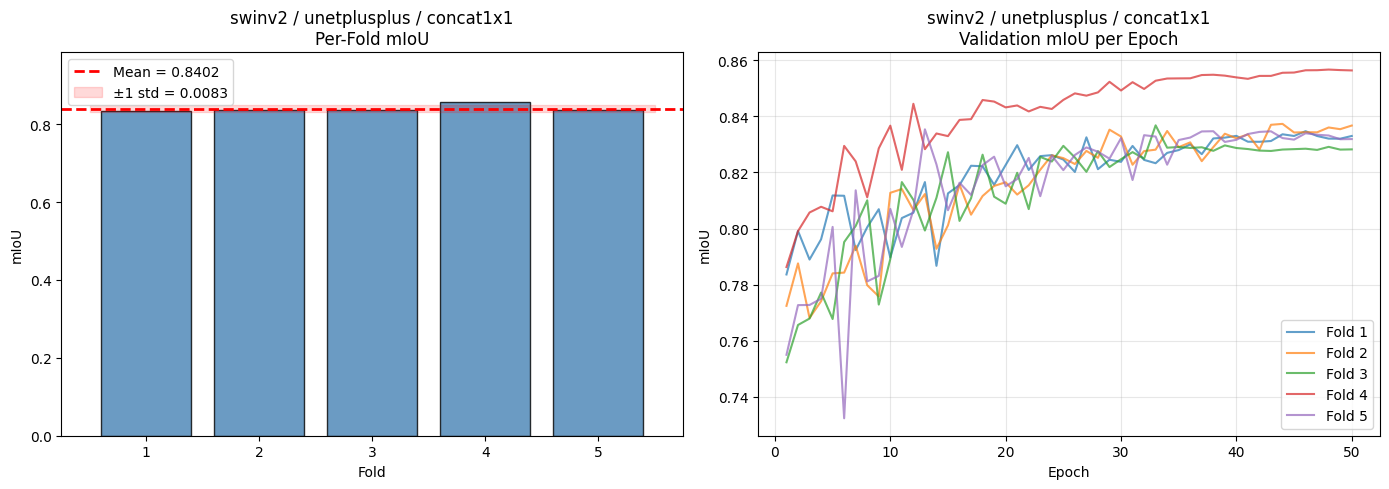


Encoder                        | Decoder         | Fusion       |         mIoU |        F1_fg |       IoU_fg
----------------------------------------------------------------------------------------------------
swinv2_small_window8_256       | unetplusplus    | concat1x1    | 0.8402±0.0083 | 0.8872±0.0074 | 0.7974±0.0121


In [7]:
# ============================================================
# Visualize K-Fold Results
# ============================================================
import matplotlib.pyplot as plt

for r in all_results:
    agg = r["aggregate_metrics"]
    tag = f"{r['encoder'].split('_')[0]} / {r['decoder']} / {r['fusion']}"

    # --- Bar chart: per-fold mIoU ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fold_mious = agg["mIoU"]["per_fold"]
    fold_f1s   = agg["F1_fg"]["per_fold"]
    folds_x = list(range(1, len(fold_mious) + 1))

    ax = axes[0]
    bars = ax.bar(folds_x, fold_mious, color="steelblue", edgecolor="black", alpha=0.8)
    ax.axhline(y=agg["mIoU"]["mean"], color="red", linestyle="--", linewidth=2,
               label=f"Mean = {agg['mIoU']['mean']:.4f}")
    ax.fill_between([0.5, len(folds_x) + 0.5],
                    agg["mIoU"]["mean"] - agg["mIoU"]["std"],
                    agg["mIoU"]["mean"] + agg["mIoU"]["std"],
                    alpha=0.15, color="red", label=f"±1 std = {agg['mIoU']['std']:.4f}")
    ax.set_xlabel("Fold"); ax.set_ylabel("mIoU")
    ax.set_title(f"{tag}\nPer-Fold mIoU")
    ax.set_xticks(folds_x)
    ax.legend()
    ax.set_ylim(0, max(fold_mious) * 1.15)

    # --- Training curves (all folds) ---
    ax = axes[1]
    for fr in r["fold_results"]:
        epochs = [e["epoch"] for e in fr["epoch_logs"]]
        mious  = [e["mIoU"]  for e in fr["epoch_logs"]]
        ax.plot(epochs, mious, label=f"Fold {fr['fold']}", alpha=0.7)
    ax.set_xlabel("Epoch"); ax.set_ylabel("mIoU")
    ax.set_title(f"{tag}\nValidation mIoU per Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(Path(cfg["out_dir"]) / f"kfold_plot_{r['decoder']}_{r['fusion']}.png", dpi=150)
    plt.show()

# --- Summary table ---
print("\n" + "=" * 100)
print(f"{'Encoder':<30s} | {'Decoder':<15s} | {'Fusion':<12s} | {'mIoU':>12s} | {'F1_fg':>12s} | {'IoU_fg':>12s}")
print("-" * 100)
for r in all_results:
    agg = r["aggregate_metrics"]
    print(f"{r['encoder']:<30s} | {r['decoder']:<15s} | {r['fusion']:<12s} | "
          f"{agg['mIoU']['mean']:.4f}±{agg['mIoU']['std']:.4f} | "
          f"{agg['F1_fg']['mean']:.4f}±{agg['F1_fg']['std']:.4f} | "
          f"{agg['IoU_fg']['mean']:.4f}±{agg['IoU_fg']['std']:.4f}")
print("=" * 100)